In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [6]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [7]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [8]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 55 concetti unici e 633 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.6474
Epoca [10/100] | Loss: 0.2171
Epoca [20/100] | Loss: 0.0649
Epoca [30/100] | Loss: 0.0282
Epoca [40/100] | Loss: 0.0146
Epoca [50/100] | Loss: 0.0091
Epoca [60/100] | Loss: 0.0068
Epoca [70/100] | Loss: 0.0055
Epoca [80/100] | Loss: 0.0048
Epoca [90/100] | Loss: 0.0044
Epoca [100/100] | Loss: 0.0041

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: leg | hops
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


### Visualization

In [9]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

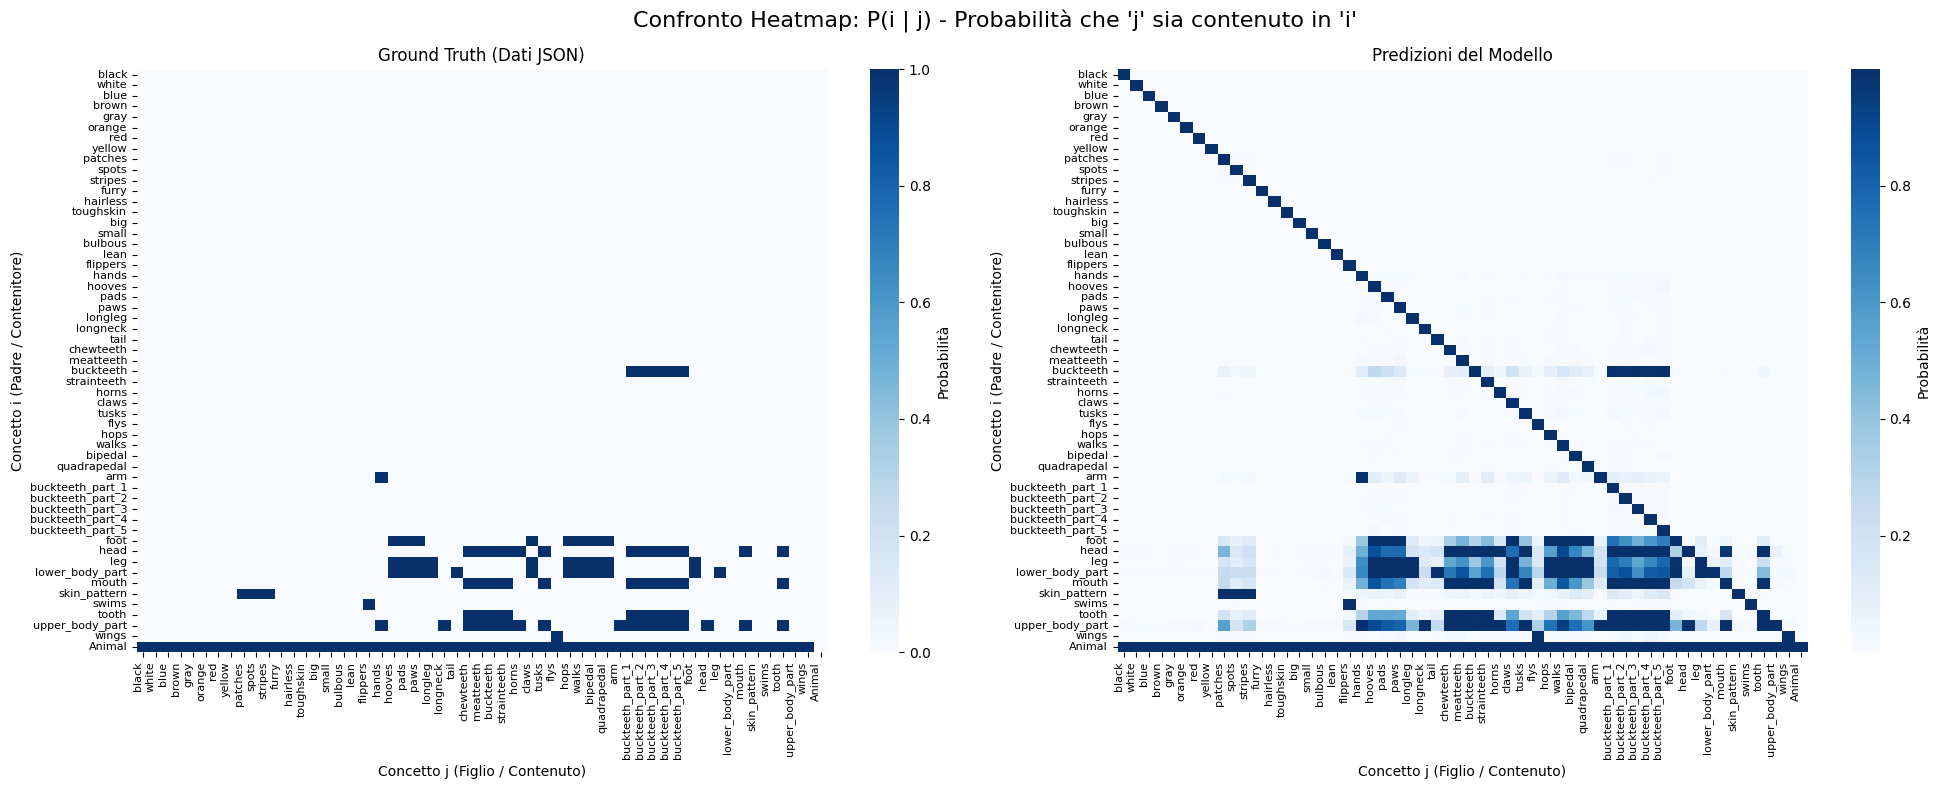

In [10]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

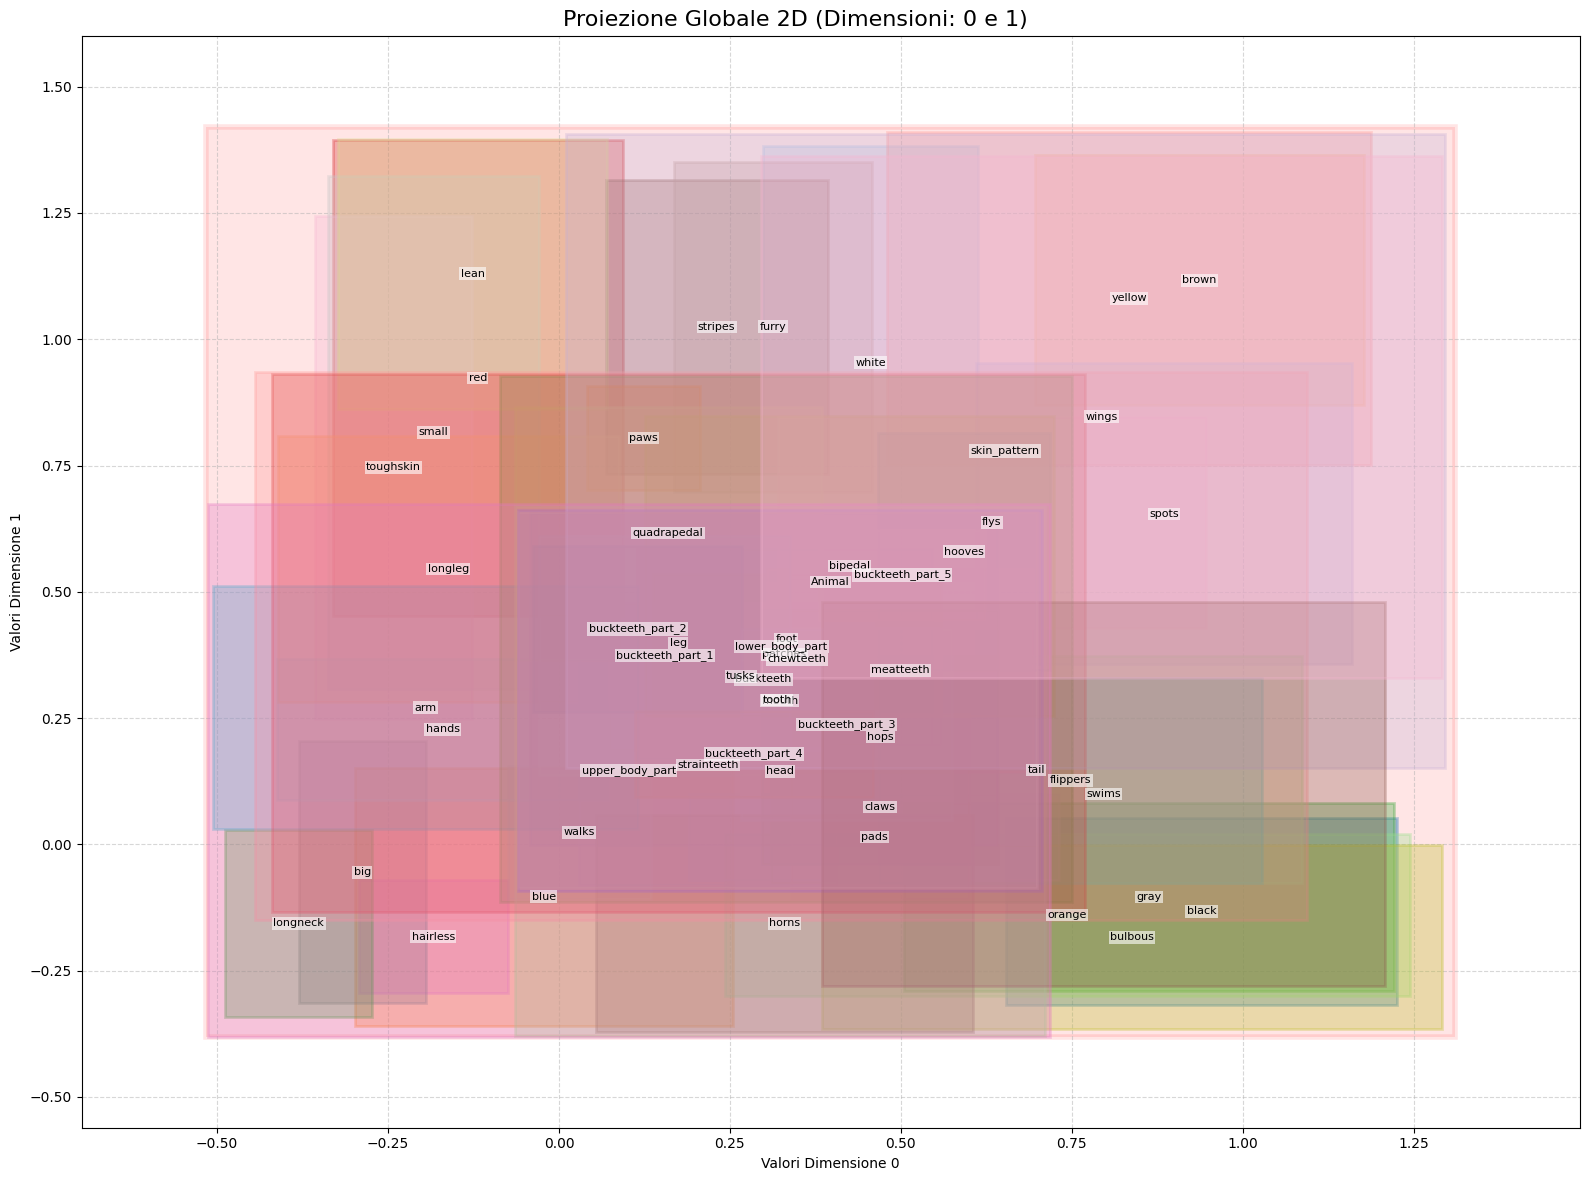

In [11]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

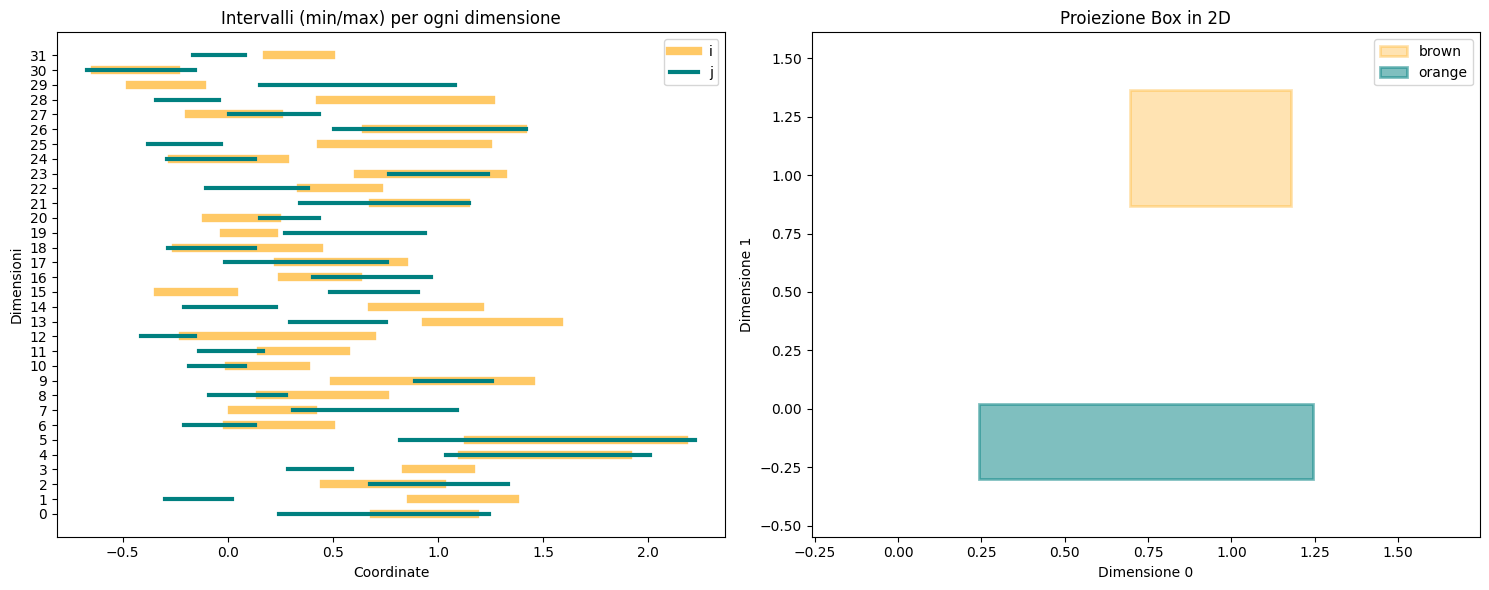

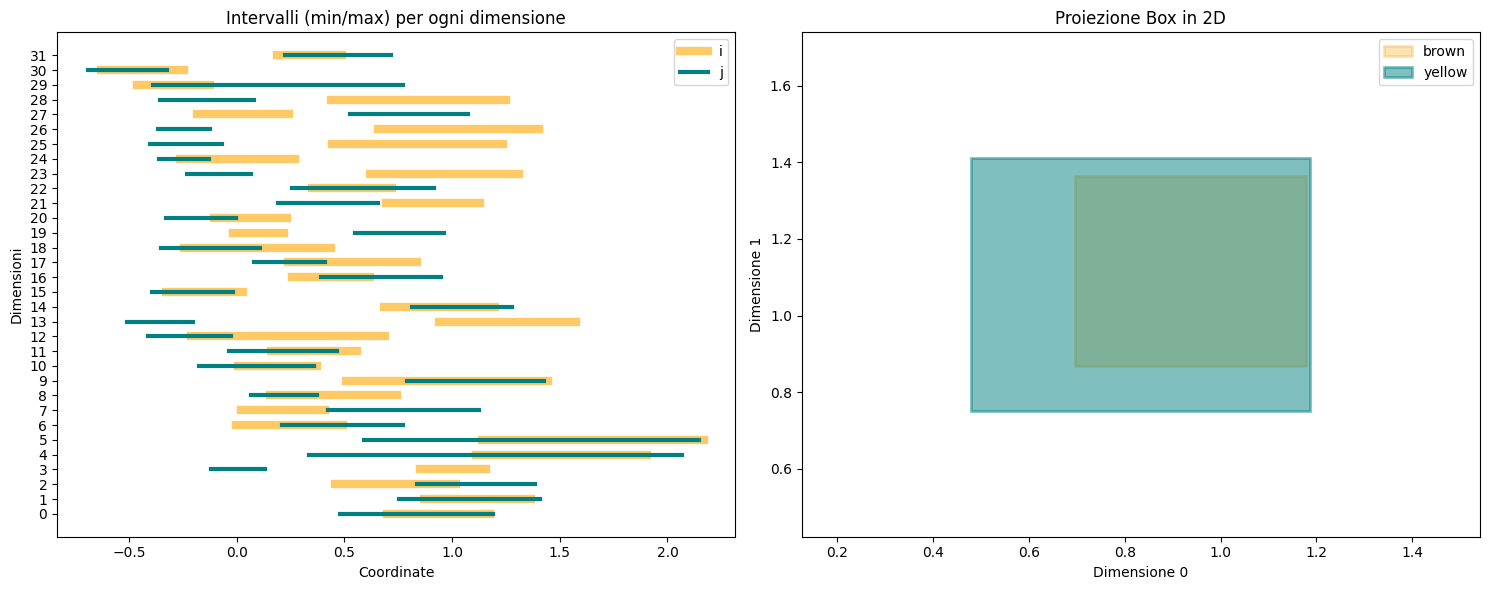

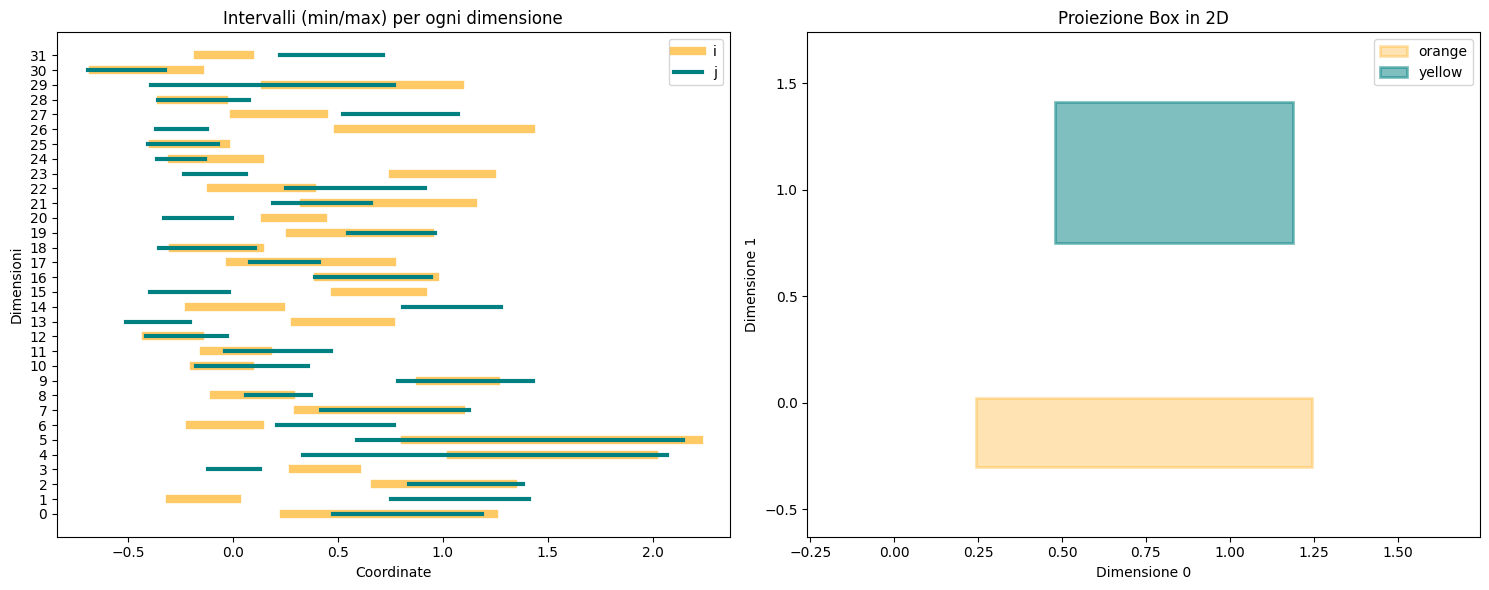

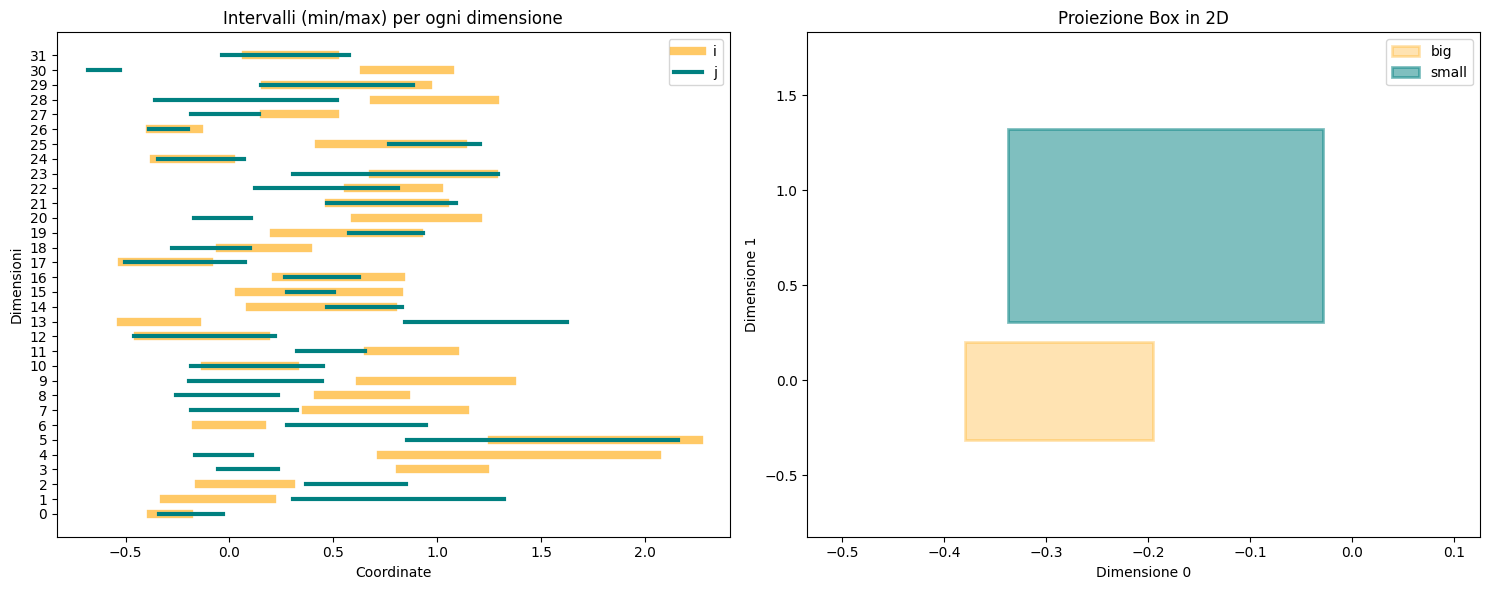

In [12]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [ ]:
from src.utils.box import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

ImportError: cannot import name 'get_box_dict' from 'src.CHM.model' (/Users/stefano_gamba/dev/BoxEmbeddingCBM/src/CHM/model.py)

## CBM

### Load dataset

In [14]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [15]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [16]:
from src.utils.box import get_box_dict
box_dict = get_box_dict(box_model, id2concept)

In [17]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [18]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
from src.CHM.test import test_cbm_classifier
from src.utils.plot import plot_test_results, plot_concept_error_heatmap, analyze_misclassifications_concepts, plot_concept_uncertainty_heatmap

### CBM with boxes

#### Train

In [19]:
b_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(b_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

info = "boxes"

b_history = train_cbm_classifier(
    b_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=0.086, Acc=98.8% | VAL: Loss=0.003, Acc=100.0%
Epoca   3/20 | TRAIN: Loss=0.002, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.000, Acc=100.0% | VA

In [ ]:
from src.utils.plot import plot_history
plot_history(b_history)

#### Test

In [20]:
accuracy, preds, labels, _, _, _ = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu"
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


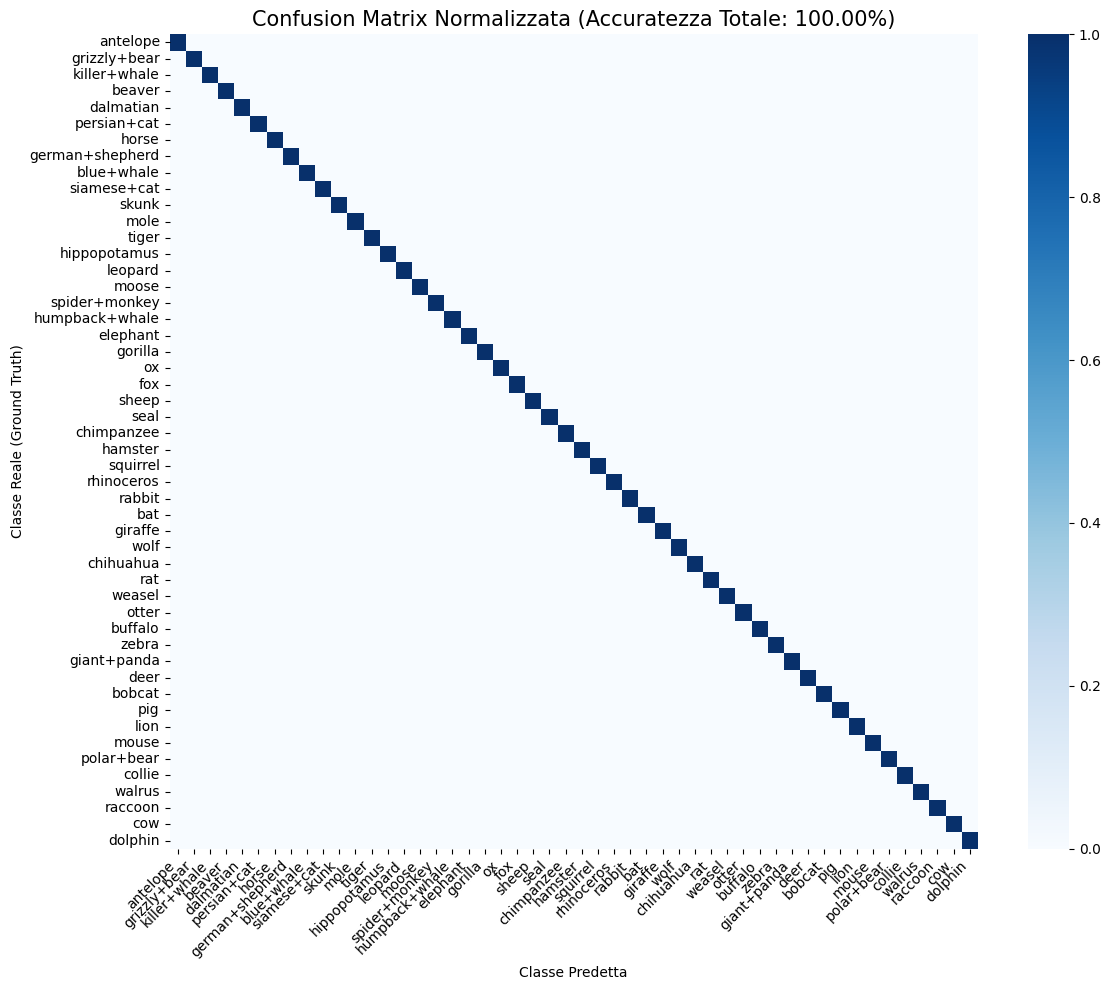


Analisi degli Errori Principali:


In [21]:
plot_test_results(accuracy, preds, labels, class_names=classes)

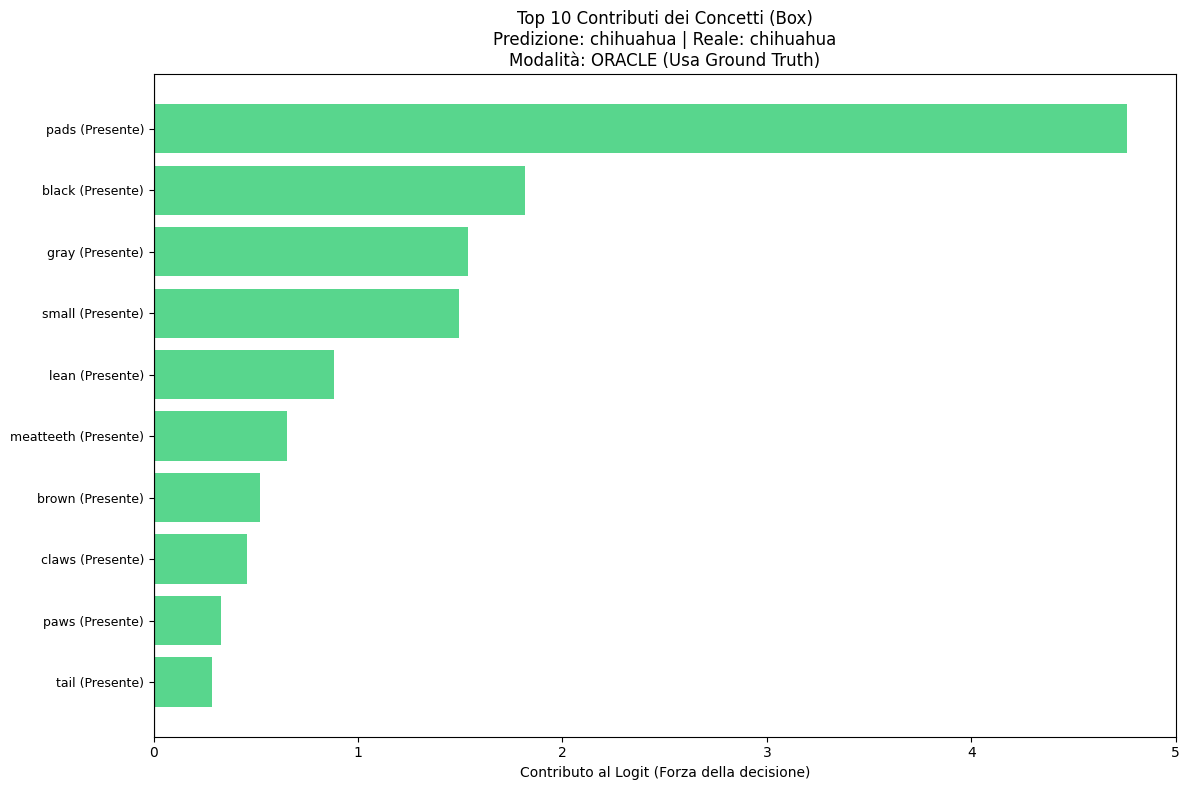

True

In [22]:
from src.CHM.interpretation import explain_prediction

explain_prediction(b_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, target_class="chihuahua")

### CBM with cond prob distrib

#### Train

In [ ]:
info = "rel_matrix"
bipolar = True
cp_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(cp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
cp_history = train_cbm_classifier(
    cp_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info,
    bipolar=bipolar
)

In [ ]:
from src.utils.plot import plot_history
plot_history(cp_history)

#### Test

In [ ]:
accuracy, preds, labels, _, _ = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=bipolar,
     oracle=True,
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class="chihuahua", 
    bipolar=bipolar
)

### CBM standard

In [ ]:
info = "concepts"
c_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(c_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
c_history = train_cbm_classifier(
    c_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

In [ ]:
from src.utils.plot import plot_history
plot_history(c_history)

In [ ]:
accuracy, preds, labels, _, _ = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     oracle=True,
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(c_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)

## Independent

### CONCEPT PREDICTOR

In [23]:
from src.CHM.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [24]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    val_dataloader, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

Loss: 3.3355 | Acc: 96.2221 || Val Loss: 2.3854 | Val Acc: 97.2496
Loss: 2.1028 | Acc: 97.6054 || Val Loss: 2.1552 | Val Acc: 97.4702
Loss: 1.8114 | Acc: 97.9141 || Val Loss: 2.1053 | Val Acc: 97.5316
Loss: 1.6515 | Acc: 98.0877 || Val Loss: 1.9947 | Val Acc: 97.6738
Loss: 1.5386 | Acc: 98.2194 || Val Loss: 2.0001 | Val Acc: 97.6558
Loss: 1.4431 | Acc: 98.3354 || Val Loss: 1.9752 | Val Acc: 97.6918
Loss: 1.3742 | Acc: 98.4207 || Val Loss: 2.0158 | Val Acc: 97.6344
Loss: 1.3201 | Acc: 98.4726 || Val Loss: 1.9846 | Val Acc: 97.7118
Loss: 1.2686 | Acc: 98.5306 || Val Loss: 2.0147 | Val Acc: 97.7035
Loss: 1.2285 | Acc: 98.5889 || Val Loss: 2.0354 | Val Acc: 97.6957
Loss: 1.1888 | Acc: 98.6348 || Val Loss: 2.0696 | Val Acc: 97.6685
Loss: 1.1655 | Acc: 98.6568 || Val Loss: 2.0505 | Val Acc: 97.6948
Loss: 1.1328 | Acc: 98.6977 || Val Loss: 2.0605 | Val Acc: 97.6782
Loss: 1.1074 | Acc: 98.7174 || Val Loss: 2.1057 | Val Acc: 97.6787
Loss: 1.0855 | Acc: 98.7482 || Val Loss: 2.1302 | Val Acc: 97.

### BOXES

In [25]:
info = "boxes"
b_accuracy, b_preds, b_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 89.90%


#### STATS 

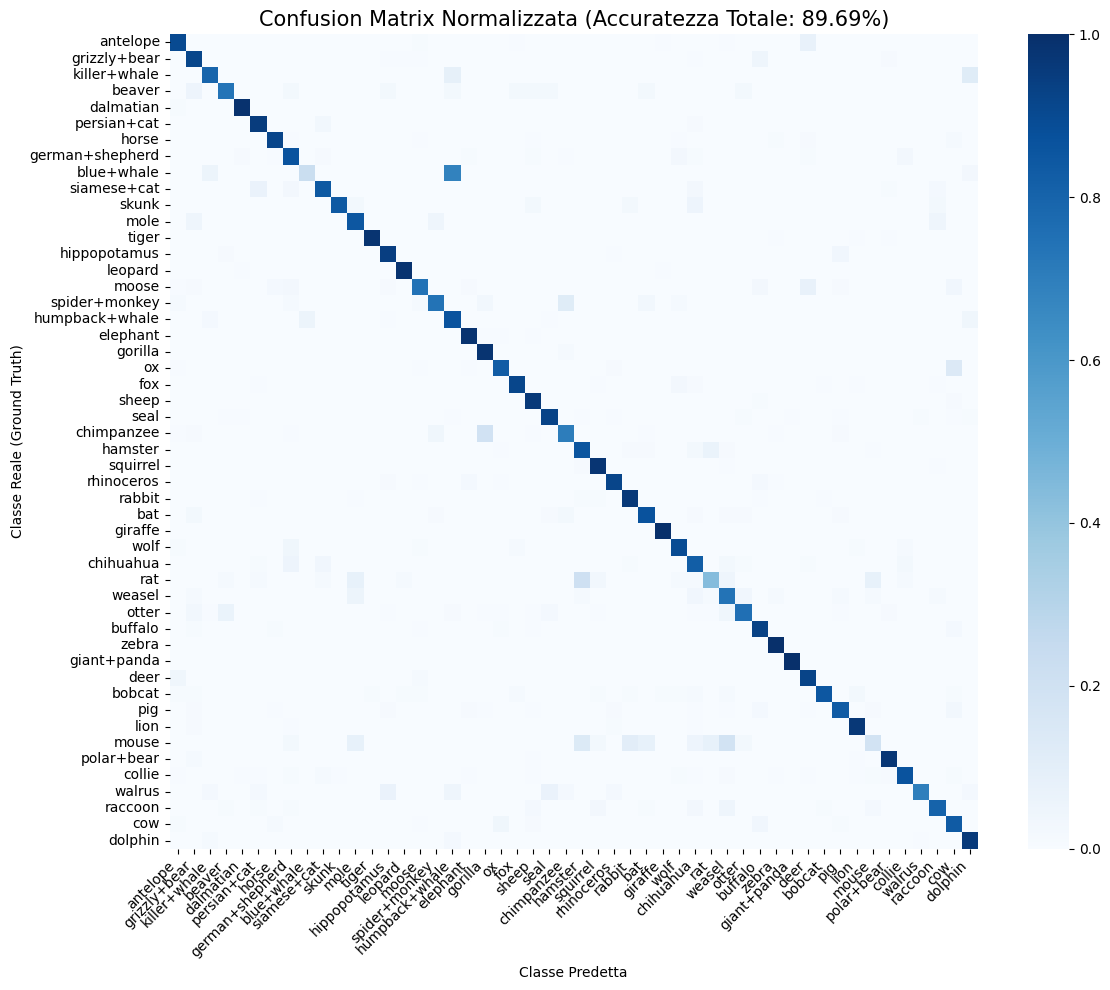


Analisi degli Errori Principali:
 - 28 volte: 'chimpanzee' è stato scambiato per 'gorilla'
 - 24 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 20 volte: 'ox' è stato scambiato per 'cow'
 - 16 volte: 'antelope' è stato scambiato per 'deer'
 - 13 volte: 'rat' è stato scambiato per 'hamster'


In [23]:
plot_test_results(b_accuracy, b_preds, b_labels, class_names=classes)

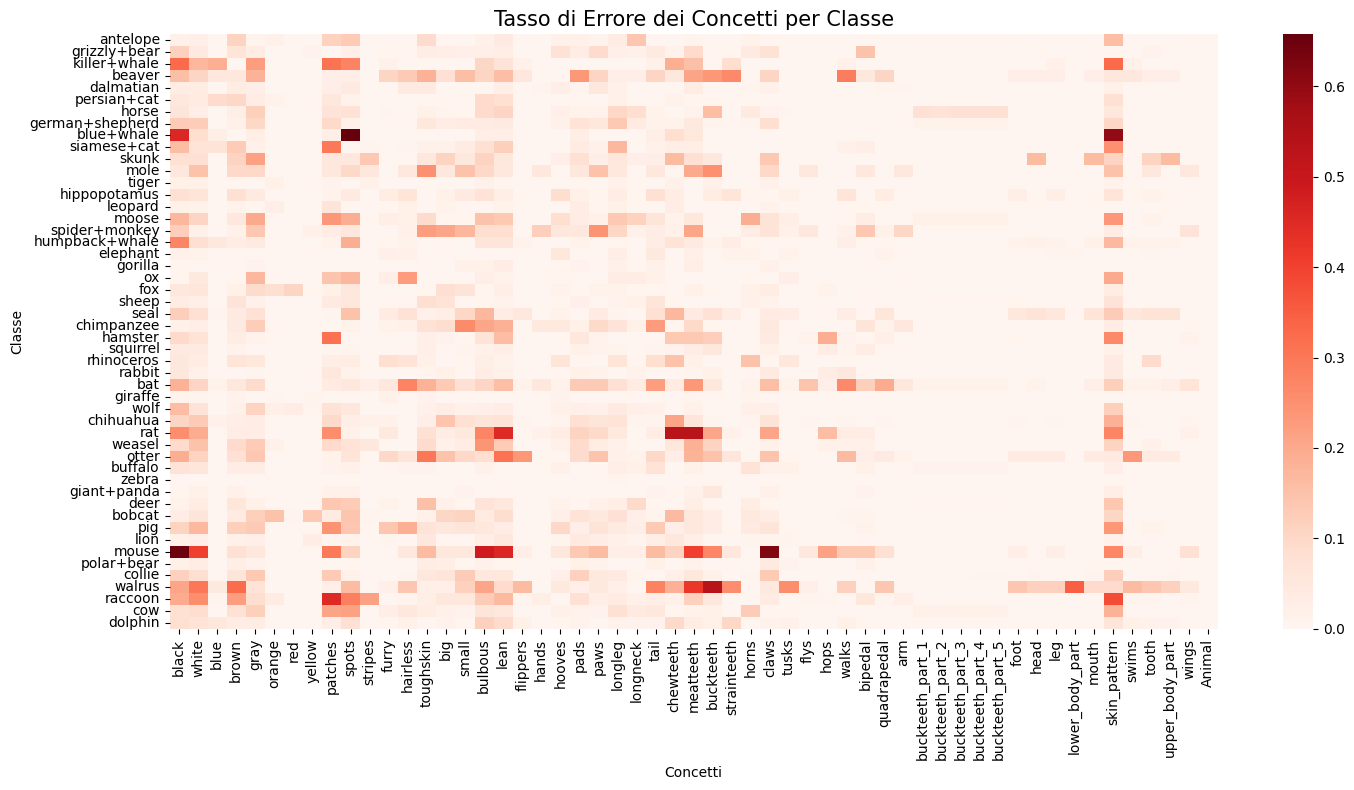

In [26]:
plot_concept_error_heatmap(labels,b_concepts_preds, b_concepts_truth, classes, concepts)

In [27]:
analyze_misclassifications_concepts(b_preds, b_labels, b_concepts_preds, b_concepts_truth, classes, concepts, num_examples=10)


--- ANALISI DEI CONCETTI SUGLI ERRORI (Mostrando 10 esempi) ---

[Esempio Errato #1 - Indice Batch: 3]
Classe Reale: 'collie' ---> Classe Predetta: 'polar+bear'
Concetti Sbagliati (Falsi Positivi / Falsi Negativi):
  - [brown] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [patches] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [small] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [bulbous] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [lean] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [pads] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [claws] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [skin_pattern] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.

[Esempio Errato #2 - Indice Batch: 7]
Classe Reale: 'walrus' ---> Classe Predetta: 'hippopotamus'
Concetti Sbagliati (Falsi Positivi / Falsi Negativi):
  - [black] Falso Posi

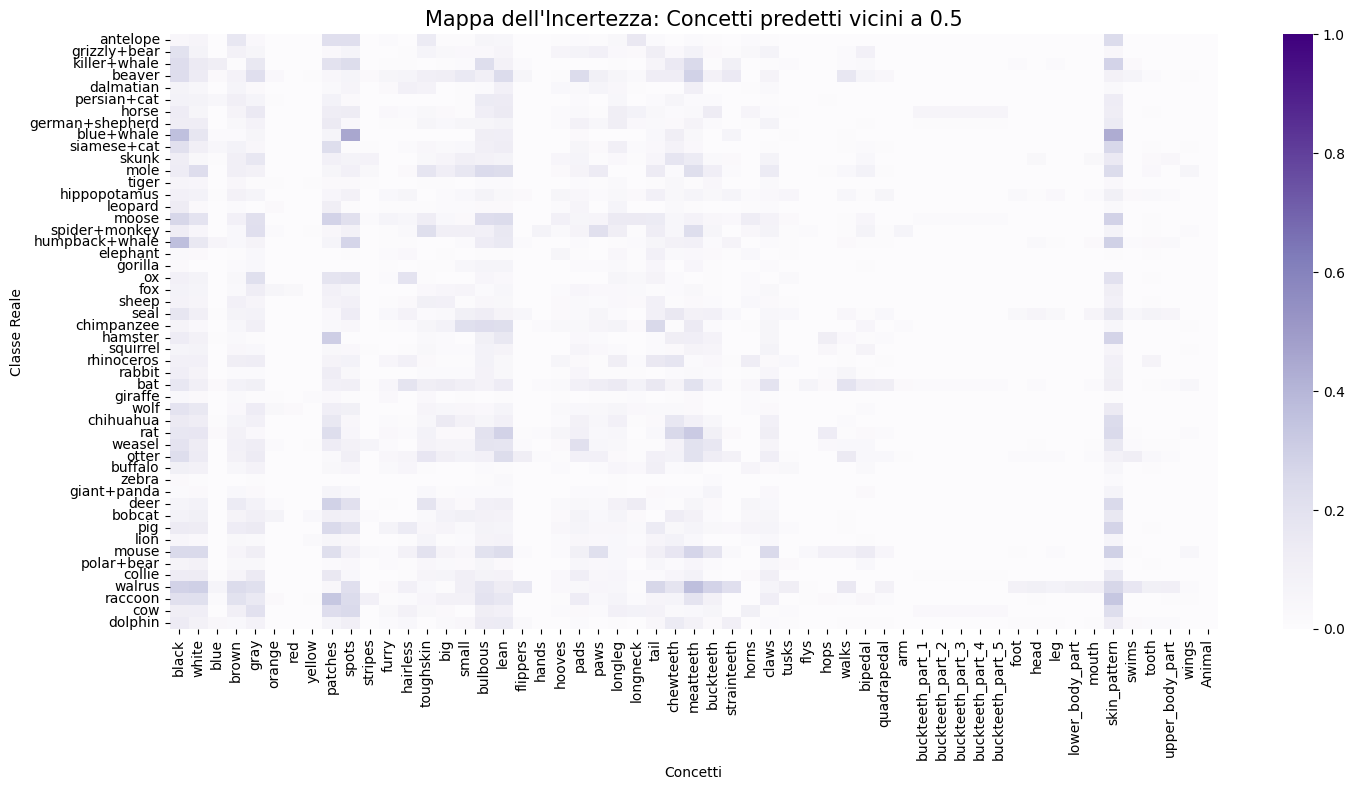

array([[4.40332592e-02, 5.87275475e-02, 6.86246276e-05, ...,
        8.53287531e-07, 2.22857925e-03, 1.93928980e-08],
       [2.02000231e-01, 7.79474974e-02, 4.51262196e-04, ...,
        4.70121671e-03, 3.77021334e-03, 1.40246226e-09],
       [2.27978334e-01, 1.45654455e-01, 1.18031666e-01, ...,
        3.73708783e-04, 1.96757191e-03, 8.22133028e-09],
       ...,
       [2.07779363e-01, 2.14057803e-01, 1.76942647e-02, ...,
        8.14159401e-03, 1.53299803e-02, 2.33743713e-09],
       [1.19841032e-01, 1.13756448e-01, 1.72971122e-04, ...,
        1.78876217e-05, 3.43731081e-04, 1.15650804e-08],
       [1.39658496e-01, 8.83936286e-02, 4.30962704e-02, ...,
        1.57338101e-02, 5.68229752e-03, 1.00917914e-08]])

In [28]:
plot_concept_uncertainty_heatmap(labels, b_concepts_probs, class_names=classes, concept_names=concepts)

#### TEST TIME INTERVENTION


--- Valutazione con k=0 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 89.90%
Inizio valutazione sul Test Set...

Accuratezza Totale: 89.90%
Inizio valutazione sul Test Set...

Accuratezza Totale: 88.10%
Inizio valutazione sul Test Set...

Accuratezza Totale: 88.10%

--- Valutazione con k=1 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.33%
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.91%
Inizio valutazione sul Test Set...

Accuratezza Totale: 88.44%
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.18%

--- Valutazione con k=2 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.49%
Inizio valutazione sul Test Set...

Accuratezza Totale: 93.41%
Inizio valutazione sul Test Set...

Accuratezza Totale: 88.55%
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.96%

--- Valutazione con k=3 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.08%
Inizio valutazione su

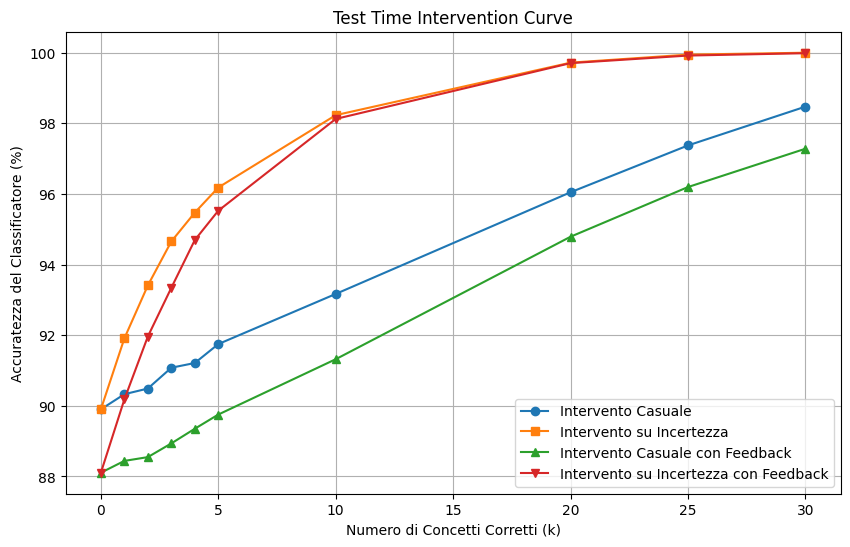

In [26]:
from src.utils.plot import plot_intervention_curve
plot_intervention_curve(
    k_values=[0,1,2,3,4,5,10,20,25,30],
    model=b_model,
    test_loader=test_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    device=device,
    info=info,
    concept_predictor=concept_predictor
)

### RELATION MATRIX

In [ ]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

### STANDARD CBM

In [ ]:
info = "concepts"
c_accuracy, c_preds, c_labels = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)